# 02. V1/V2 Boundary Exploration

This notebook examines the V1/V2 boundary in the developing human cortex at GW20, using the Qian/Walsh et al. 2025 MERFISH atlas. Goals:

1. Verify the sharp molecular V1/V2 boundary is visible in our data
2. Identify the best section(s) for downstream CCC analysis
3. Characterize the spatial distribution of cell types across the boundary
4. Establish the V1/V2 analytical subset for subsequent notebooks

Prerequisites: `01_data_inspection.ipynb` must have been run to generate `data/processed/main_merfish_obs_harmonized.csv`.

In [9]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)  # quieter scanpy output

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad

from src.data_loading import load_main_merfish, get_project_root

# Standard plot settings
sc.settings.set_figure_params(dpi=100, figsize=(8, 8))
plt.rcParams['figure.facecolor'] = 'white'

PROJECT_ROOT = get_project_root()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/sydneycole/neuro/neuro


In [10]:
# Load in backed mode for memory efficiency
main_merfish = load_main_merfish(PROJECT_ROOT, backed='r')
print(f"Master file: {main_merfish.shape}")
print(f"Has harmonized column: {'harmonized' in main_merfish.obs.columns}")

/opt/anaconda3/envs/neurospatial/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/sydneycole/neuro/neuro/src/data_loading.py:64: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  harmonized_df = pd.read_csv(harmonized_csv, index_col=0)


Master file: (15927370, 300)
Has harmonized column: True


## Finding sections that span the V1/V2 boundary

A useful section for V1/V2 boundary analysis must contain *both* V1 and V2 cells in a single physical tissue piece (same `sample`, same `region`). This lets us see the boundary directly rather than inferring it across multiple sections.

The paper's clearest V1/V2 boundary findings come from GW20, particularly FB080's occipital sections (FB080-O1, FB080-O1c). Let's identify which `(sample, region)` combinations have both V1 and V2 cells.

In [11]:
# Get the GW20 V1/V2 cells (CP/MZ only, since that's where area labels exist)
# Use the area column directly as the filter — V1/V2 labels only exist where they're meaningful
gw20_v1v2_mask = (
    (main_merfish.obs['gw'] == '20') &
    (main_merfish.obs['area'].isin(['A-V1', 'B-V1', 'A-V2', 'B-V2']))
)
gw20_v1v2_obs = main_merfish.obs[gw20_v1v2_mask].copy()

# Find sections containing BOTH V1 and V2 cells
def get_v1_v2_labels(area_series):
    """Categorize area labels as V1, V2, or other."""
    labels = set()
    for a in area_series.unique():
        if 'V1' in a:
            labels.add('V1')
        elif 'V2' in a:
            labels.add('V2')
    return labels

section_summary = gw20_v1v2_obs.groupby(['sample', 'region']).agg(
    n_cells=('area', 'size'),
    n_v1=('area', lambda x: x.isin(['A-V1', 'B-V1']).sum()),
    n_v2=('area', lambda x: x.isin(['A-V2', 'B-V2']).sum()),
    areas_present=('area', lambda x: ', '.join(sorted(x.unique())))
).reset_index()

# Sections with both V1 and V2 cells are boundary-spanning
section_summary['has_both'] = (section_summary['n_v1'] > 0) & (section_summary['n_v2'] > 0)
boundary_sections = section_summary[section_summary['has_both']].sort_values('n_cells', ascending=False)

print("Sections containing BOTH V1 and V2 at GW20 (in CP/MZ layers):")
print(boundary_sections.to_string(index=False))

print("\nAll GW20 V1/V2 sections (for reference):")
print(section_summary.sort_values('n_cells', ascending=False).to_string(index=False))

Sections containing BOTH V1 and V2 at GW20 (in CP/MZ layers):
sample region  n_cells     n_v1     n_v2 areas_present  has_both
 FB080    O1a   240096 113719.0 126377.0    A-V2, B-V1      True
 FB080    O1c   197170  95127.0 102043.0    A-V1, B-V2      True
 FB080    O1b   193015 102979.0  90036.0    A-V1, B-V2      True
 FB121     O1    60269  46799.0  13470.0    A-V1, B-V2      True

All GW20 V1/V2 sections (for reference):
 sample region  n_cells     n_v1     n_v2 areas_present  has_both
  FB080    O1a   240096 113719.0 126377.0    A-V2, B-V1      True
  FB080    O1c   197170  95127.0 102043.0    A-V1, B-V2      True
  FB080    O1b   193015 102979.0  90036.0    A-V1, B-V2      True
  FB121     O1    60269  46799.0  13470.0    A-V1, B-V2      True
UMB1367   BA22        0      NaN      NaN           NaN     False
UMB1117     P2        0      NaN      NaN           NaN     False
UMB1117     T1        0      NaN      NaN           NaN     False
UMB1367    BA4        0      NaN      NaN  

In [12]:
# Select the largest boundary-spanning section
TARGET_SAMPLE = 'FB080'
TARGET_REGION = 'O1b' 

# Subset and convert to in-memory AnnData for fast plotting
section_mask = (
    (main_merfish.obs['sample'] == TARGET_SAMPLE) &
    (main_merfish.obs['region'] == TARGET_REGION)
)
section = main_merfish[section_mask].to_memory()

print(f"Selected section: {TARGET_SAMPLE} {TARGET_REGION}")
print(f"Cells: {section.shape[0]}")
print(f"\nArea composition:")
print(section.obs['area'].value_counts(dropna=False))
print(f"\nLayer composition:")
print(section.obs['layer'].value_counts(dropna=False))
print(f"\nHarmonized cell type composition:")
print(section.obs['harmonized'].value_counts(dropna=False))

Selected section: FB080 O1b
Cells: 332353

Area composition:
area
NaN     139338
A-V1    102979
B-V2     90036
Name: count, dtype: int64

Layer composition:
layer
NaN     139338
osvz     49950
iz       38317
l6       29272
l3       24193
sp       14192
l5       12368
isvz      8721
mz        8303
l4        5561
vz        2138
Name: count, dtype: int64

Harmonized cell type composition:
harmonized
NaN          149201
EN-ET         60687
EN-IT-UL      58251
EN-IT-DL      40484
IN            14839
Astrocyte      3885
EC             3712
Glia           1294
Name: count, dtype: int64


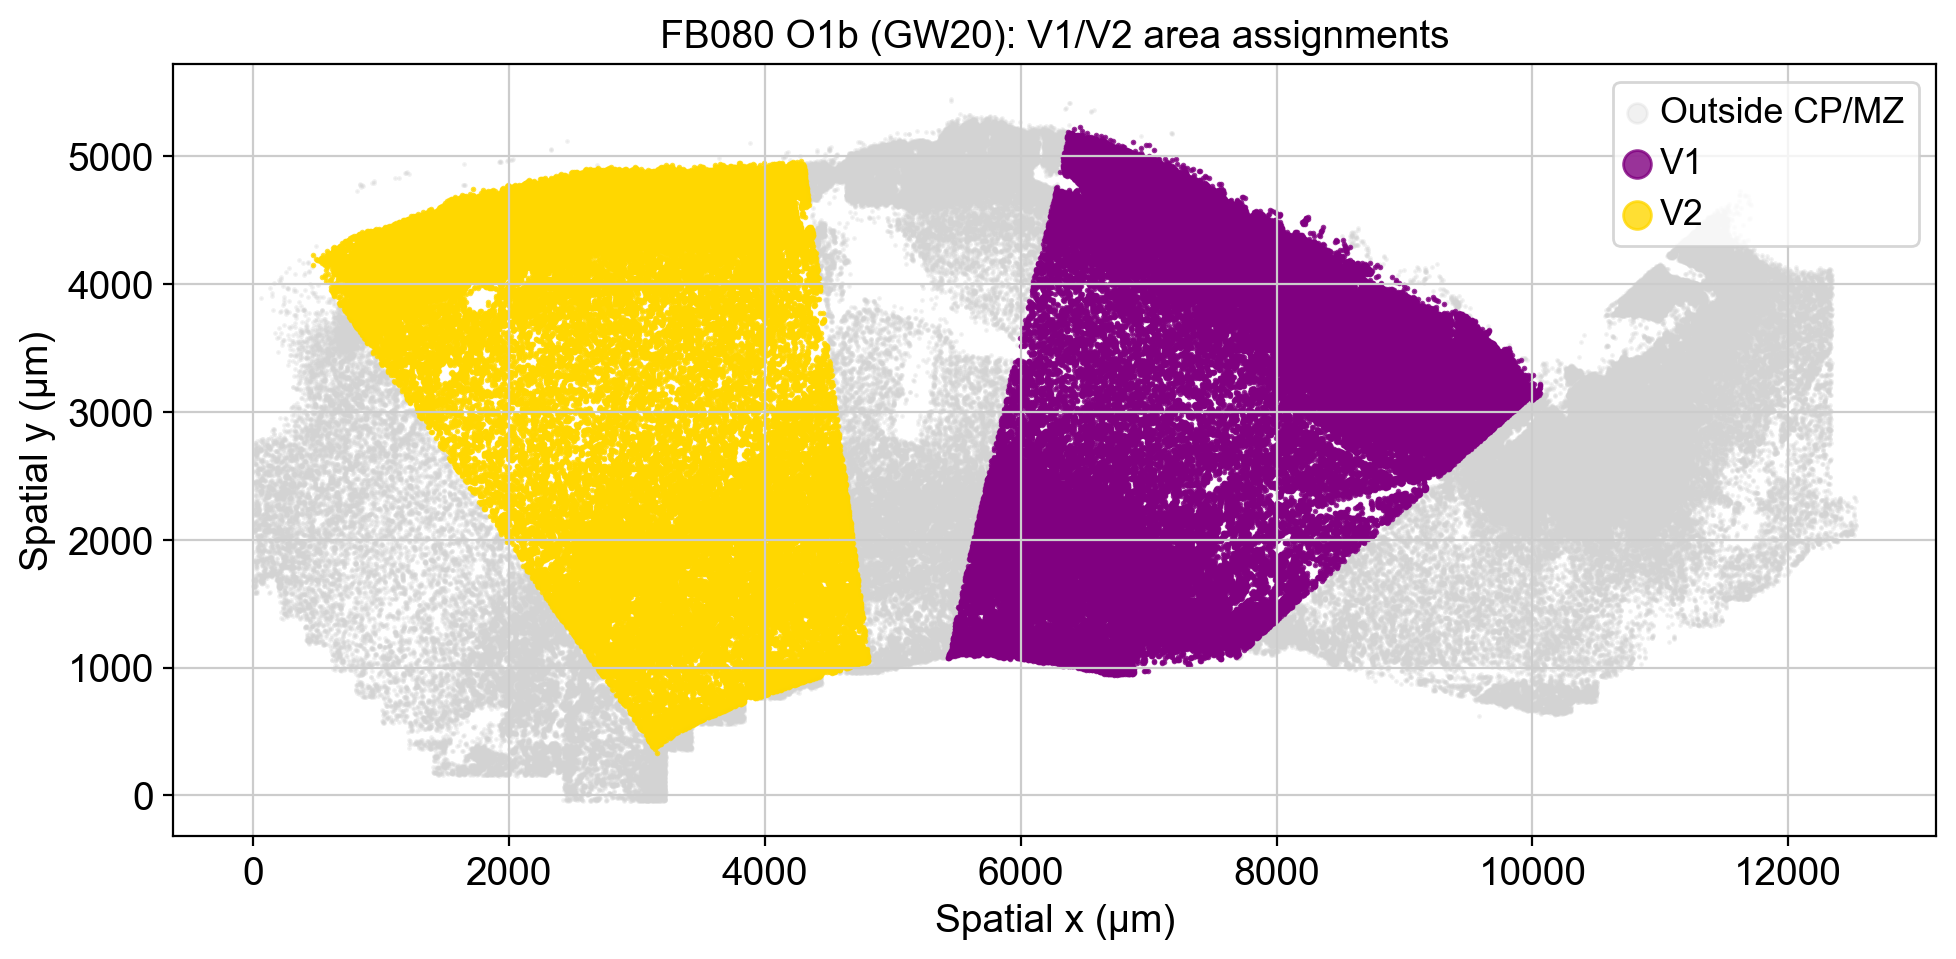

In [13]:
# Plot all cells in the section, colored by area
# Cells with NaN area (deeper layers) get a neutral gray

fig, ax = plt.subplots(figsize=(10, 12))

# Plot NaN cells first as background (deeper layers, no V1/V2 distinction)
nan_mask = section.obs['area'].isna()
ax.scatter(
    section.obsm['spatial'][nan_mask, 0],
    section.obsm['spatial'][nan_mask, 1],
    c='lightgray', s=0.5, alpha=0.3, label='Outside CP/MZ'
)

# Plot V1 cells
v1_mask = section.obs['area'].isin(['A-V1', 'B-V1'])
ax.scatter(
    section.obsm['spatial'][v1_mask, 0],
    section.obsm['spatial'][v1_mask, 1],
    c='purple', s=1, alpha=0.8, label='V1'
)

# Plot V2 cells
v2_mask = section.obs['area'].isin(['A-V2', 'B-V2'])
ax.scatter(
    section.obsm['spatial'][v2_mask, 0],
    section.obsm['spatial'][v2_mask, 1],
    c='gold', s=1, alpha=0.8, label='V2'
)

ax.set_aspect('equal')
ax.set_title(f'{TARGET_SAMPLE} {TARGET_REGION} (GW20): V1/V2 area assignments')
ax.set_xlabel('Spatial x (μm)')
ax.set_ylabel('Spatial y (μm)')
ax.legend(loc='upper right', markerscale=10)
plt.tight_layout()
plt.show()

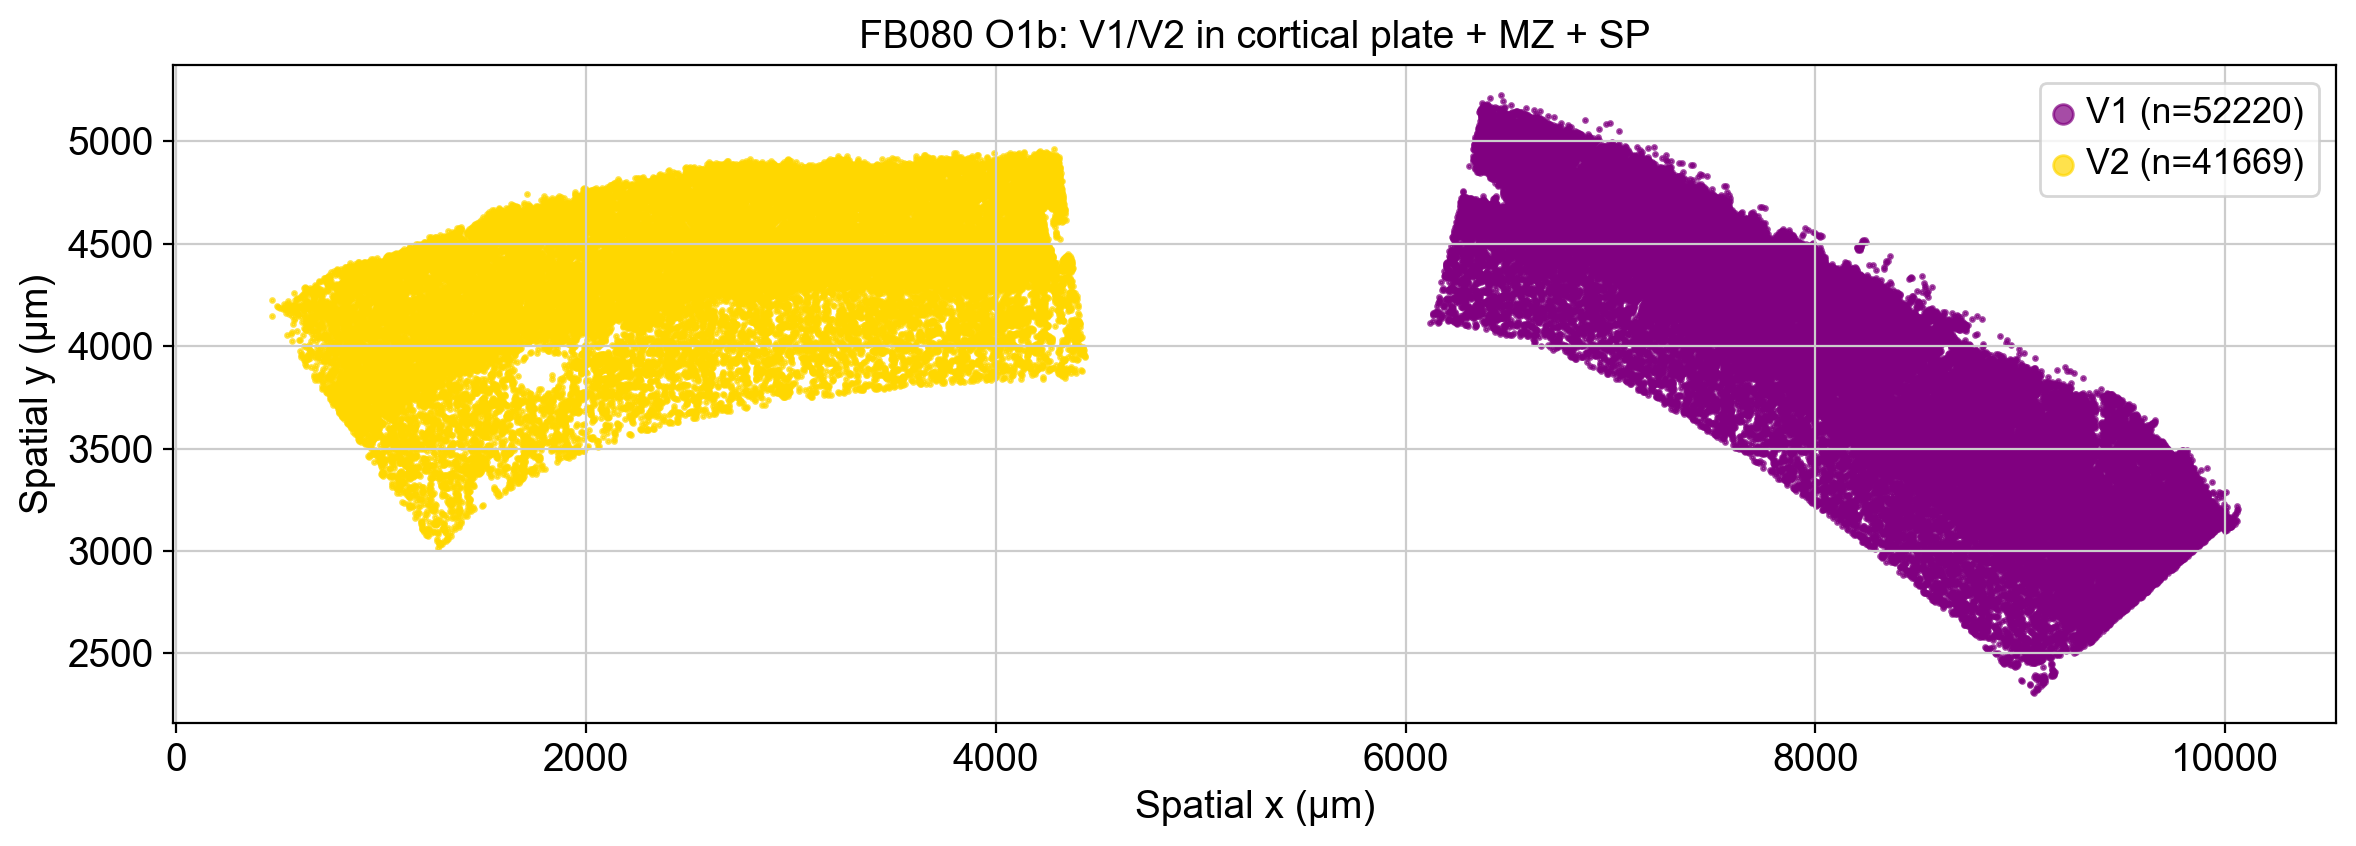

In [16]:
# Filter to just CP/MZ layers (where V1/V2 distinction exists)
cp_mz_mask = section.obs['layer'].isin(['mz', 'l2', 'l3', 'l4', 'l5', 'l6', 'sp'])
cp_section = section[cp_mz_mask]

fig, ax = plt.subplots(figsize=(12, 12))

# V1 cells
v1_mask = cp_section.obs['area'].isin(['A-V1', 'B-V1'])
ax.scatter(
    cp_section.obsm['spatial'][v1_mask, 0],
    cp_section.obsm['spatial'][v1_mask, 1],
    c='purple', s=2, alpha=0.7, label=f'V1 (n={v1_mask.sum()})'
)

# V2 cells
v2_mask = cp_section.obs['area'].isin(['A-V2', 'B-V2'])
ax.scatter(
    cp_section.obsm['spatial'][v2_mask, 0],
    cp_section.obsm['spatial'][v2_mask, 1],
    c='gold', s=2, alpha=0.7, label=f'V2 (n={v2_mask.sum()})'
)

# Cells in CP/MZ but without area assignment (shouldn't be many)
nan_mask = cp_section.obs['area'].isna()
if nan_mask.sum() > 0:
    ax.scatter(
        cp_section.obsm['spatial'][nan_mask, 0],
        cp_section.obsm['spatial'][nan_mask, 1],
        c='lightgray', s=1, alpha=0.3, label=f'CP/MZ, no area (n={nan_mask.sum()})'
    )

ax.set_aspect('equal')
ax.set_title(f'{TARGET_SAMPLE} {TARGET_REGION}: V1/V2 in cortical plate + MZ + SP')
ax.set_xlabel('Spatial x (μm)')
ax.set_ylabel('Spatial y (μm)')
ax.legend(loc='upper right', markerscale=5)
plt.tight_layout()
plt.show()

In [17]:
cp_mz_nan = (
    section.obs['layer'].isin(['mz', 'l2', 'l3', 'l4', 'l5', 'l6', 'sp']) &
    section.obs['area'].isna()
)
print(f"CP/MZ cells with NaN area: {cp_mz_nan.sum()}")
print(f"Their layer distribution: ")
print(section.obs[cp_mz_nan]['layer'].value_counts())

CP/MZ cells with NaN area: 0
Their layer distribution: 
layer
isvz    0
iz      0
l3      0
l4      0
l5      0
l6      0
mz      0
osvz    0
sp      0
vz      0
Name: count, dtype: int64


In [18]:
import numpy as np

# Get V1 and V2 cell coordinates from the CP-only subset
v1_coords = cp_section.obsm['spatial'][cp_section.obs['area'].isin(['A-V1', 'B-V1'])]
v2_coords = cp_section.obsm['spatial'][cp_section.obs['area'].isin(['A-V2', 'B-V2'])]

# Find the closest V2 cell for each V1 cell (this gives "distance to nearest V2")
from scipy.spatial import cKDTree

tree_v2 = cKDTree(v2_coords)
distances_v1_to_v2, _ = tree_v2.query(v1_coords, k=1)

print(f"Distance from each V1 cell to nearest V2 cell (in microns):")
print(f"  Min:    {distances_v1_to_v2.min():.1f}")
print(f"  Median: {np.median(distances_v1_to_v2):.1f}")
print(f"  Mean:   {distances_v1_to_v2.mean():.1f}")
print(f"  Max:    {distances_v1_to_v2.max():.1f}")

# What does typical cell-to-cell spacing look like within V1?
tree_v1 = cKDTree(v1_coords)
distances_within_v1, _ = tree_v1.query(v1_coords, k=2)  # 2nd closest because self is closest
nearest_v1_to_v1 = distances_within_v1[:, 1]

print(f"\nDistance to nearest V1 cell from each V1 cell (cell spacing within V1):")
print(f"  Min:    {nearest_v1_to_v1.min():.1f}")
print(f"  Median: {np.median(nearest_v1_to_v1):.1f}")
print(f"  Mean:   {nearest_v1_to_v1.mean():.1f}")

Distance from each V1 cell to nearest V2 cell (in microns):
  Min:    1692.6
  Median: 3803.4
  Mean:   3761.0
  Max:    5679.9

Distance to nearest V1 cell from each V1 cell (cell spacing within V1):
  Min:    2.2
  Median: 6.1
  Mean:   6.3


In [19]:
# Switch the target section temporarily to check O1c
TARGET_REGION_TEST = 'O1c'
section_mask_test = (
    (main_merfish.obs['sample'] == 'FB080') &
    (main_merfish.obs['region'] == TARGET_REGION_TEST)
)
section_test = main_merfish[section_mask_test].to_memory()

cp_test_mask = section_test.obs['layer'].isin(['mz', 'l2', 'l3', 'l4', 'l5', 'l6', 'sp'])
cp_test = section_test[cp_test_mask]

v1_test = cp_test.obsm['spatial'][cp_test.obs['area'].isin(['A-V1', 'B-V1'])]
v2_test = cp_test.obsm['spatial'][cp_test.obs['area'].isin(['A-V2', 'B-V2'])]

if len(v1_test) > 0 and len(v2_test) > 0:
    from scipy.spatial import cKDTree
    tree = cKDTree(v2_test)
    d, _ = tree.query(v1_test, k=1)
    print(f"FB080-O1c V1-to-V2 distances (in μm):")
    print(f"  Min:    {d.min():.1f}")
    print(f"  Median: {np.median(d):.1f}")
    print(f"  Mean:   {d.mean():.1f}")
else:
    print(f"FB080-O1c has only V1 or only V2 cells, not both")

FB080-O1c V1-to-V2 distances (in μm):
  Min:    1506.4
  Median: 3310.8
  Mean:   3322.4


In [20]:
import numpy as np

# Examine the full spatial coordinate distribution of FB080-O1b
v1_coords_o1b = section.obsm['spatial'][section.obs['area'].isin(['A-V1', 'B-V1'])]
v2_coords_o1b = section.obsm['spatial'][section.obs['area'].isin(['A-V2', 'B-V2'])]

print(f"V1 spatial extent:")
print(f"  x: {v1_coords_o1b[:,0].min():.0f} to {v1_coords_o1b[:,0].max():.0f} (width: {v1_coords_o1b[:,0].max() - v1_coords_o1b[:,0].min():.0f} μm)")
print(f"  y: {v1_coords_o1b[:,1].min():.0f} to {v1_coords_o1b[:,1].max():.0f} (height: {v1_coords_o1b[:,1].max() - v1_coords_o1b[:,1].min():.0f} μm)")

print(f"\nV2 spatial extent:")
print(f"  x: {v2_coords_o1b[:,0].min():.0f} to {v2_coords_o1b[:,0].max():.0f} (width: {v2_coords_o1b[:,0].max() - v2_coords_o1b[:,0].min():.0f} μm)")
print(f"  y: {v2_coords_o1b[:,1].min():.0f} to {v2_coords_o1b[:,1].max():.0f} (height: {v2_coords_o1b[:,1].max() - v2_coords_o1b[:,1].min():.0f} μm)")

print(f"\nDistance between centroids:")
v1_center = v1_coords_o1b.mean(axis=0)
v2_center = v2_coords_o1b.mean(axis=0)
dist = np.linalg.norm(v1_center - v2_center)
print(f"  V1 centroid: ({v1_center[0]:.0f}, {v1_center[1]:.0f})")
print(f"  V2 centroid: ({v2_center[0]:.0f}, {v2_center[1]:.0f})")
print(f"  Centroid distance: {dist:.0f} μm")

V1 spatial extent:
  x: 5427 to 10063 (width: 4636 μm)
  y: 944 to 5225 (height: 4281 μm)

V2 spatial extent:
  x: 465 to 4806 (width: 4341 μm)
  y: 332 to 4961 (height: 4629 μm)

Distance between centroids:
  V1 centroid: (7491, 2957)
  V2 centroid: (3030, 3061)
  Centroid distance: 4462 μm


## Note on tissue structure

FB080-O1b consists of two separately-imaged tissue pieces: a V1 region 
(x ≈ 5400–10000 μm) and a V2 region (x ≈ 500–4800 μm), with a ~620 μm gap 
between them. This is consistent with the dataset's dissection-and-imaging 
strategy for large fetal brain tissue. The V1/V2 molecular boundary 
described in Qian/Walsh et al. 2025 reflects differential molecular 
identity between the two dissected regions, not a continuous tissue 
boundary preserved in imaging.

This has two implications for CCC analysis:

1. **V1 vs V2 population comparison is straightforward** — each population 
   has dense, well-characterized cells suitable for CCC inference.
2. **Within-piece spatial structure is intact** — COMMOT will compute 
   meaningful local neighborhoods within each piece.
3. **CCC analysis should be run separately on V1 and V2 cells**, then 
   compared, to avoid any cross-piece interaction artifacts.

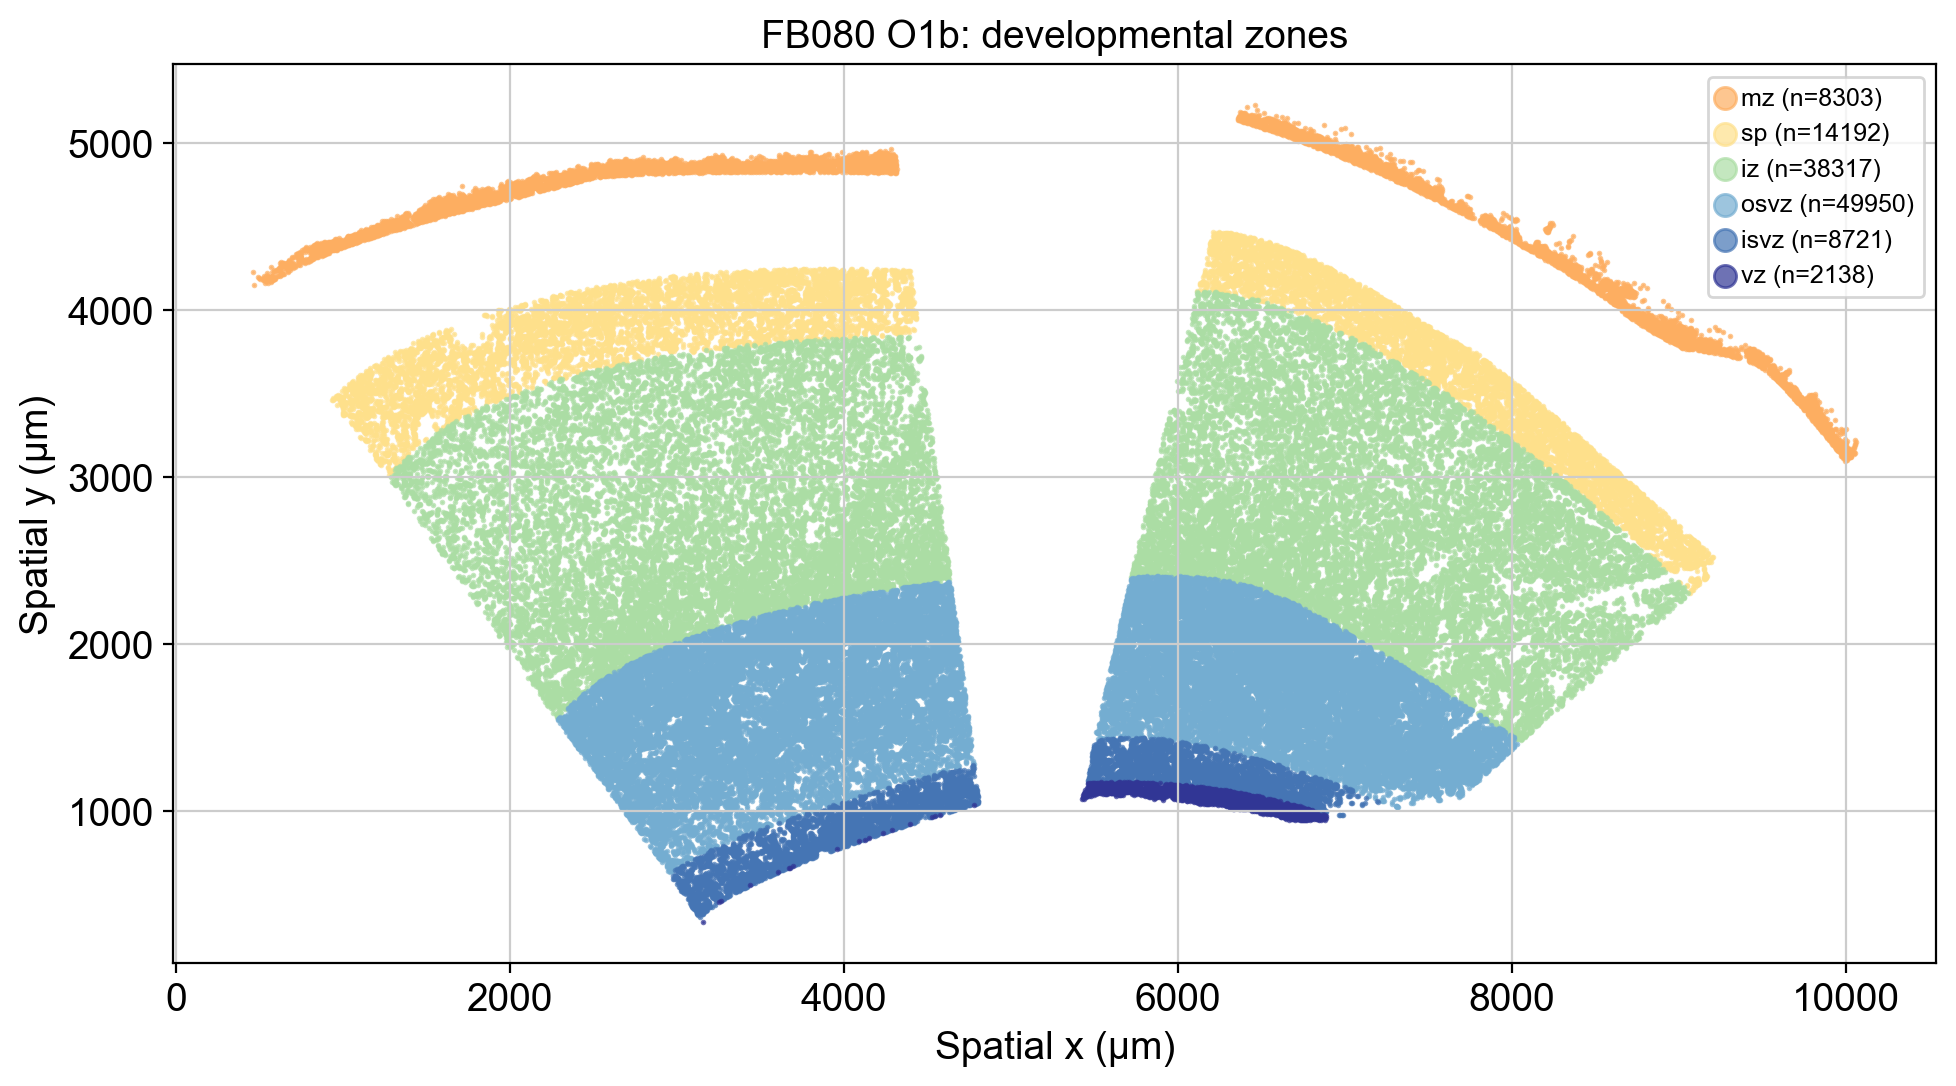

In [14]:
# Plot all cells by layer to understand the tissue structure
layer_palette = {
    'mz': '#fdae61',
    'cp': '#d7191c',
    'sp': '#fee08b',
    'iz': '#abdda4',
    'osvz': '#74add1',
    'isvz': '#4575b4',
    'vz': '#313695',
}

fig, ax = plt.subplots(figsize=(10, 12))

for layer_name, color in layer_palette.items():
    mask = section.obs['layer'] == layer_name
    if mask.sum() == 0:
        continue
    ax.scatter(
        section.obsm['spatial'][mask, 0],
        section.obsm['spatial'][mask, 1],
        c=color, s=1, alpha=0.7, label=f'{layer_name} (n={mask.sum()})'
    )

ax.set_aspect('equal')
ax.set_title(f'{TARGET_SAMPLE} {TARGET_REGION}: developmental zones')
ax.set_xlabel('Spatial x (μm)')
ax.set_ylabel('Spatial y (μm)')
ax.legend(loc='upper right', markerscale=8, fontsize=9)
plt.tight_layout()
plt.show()

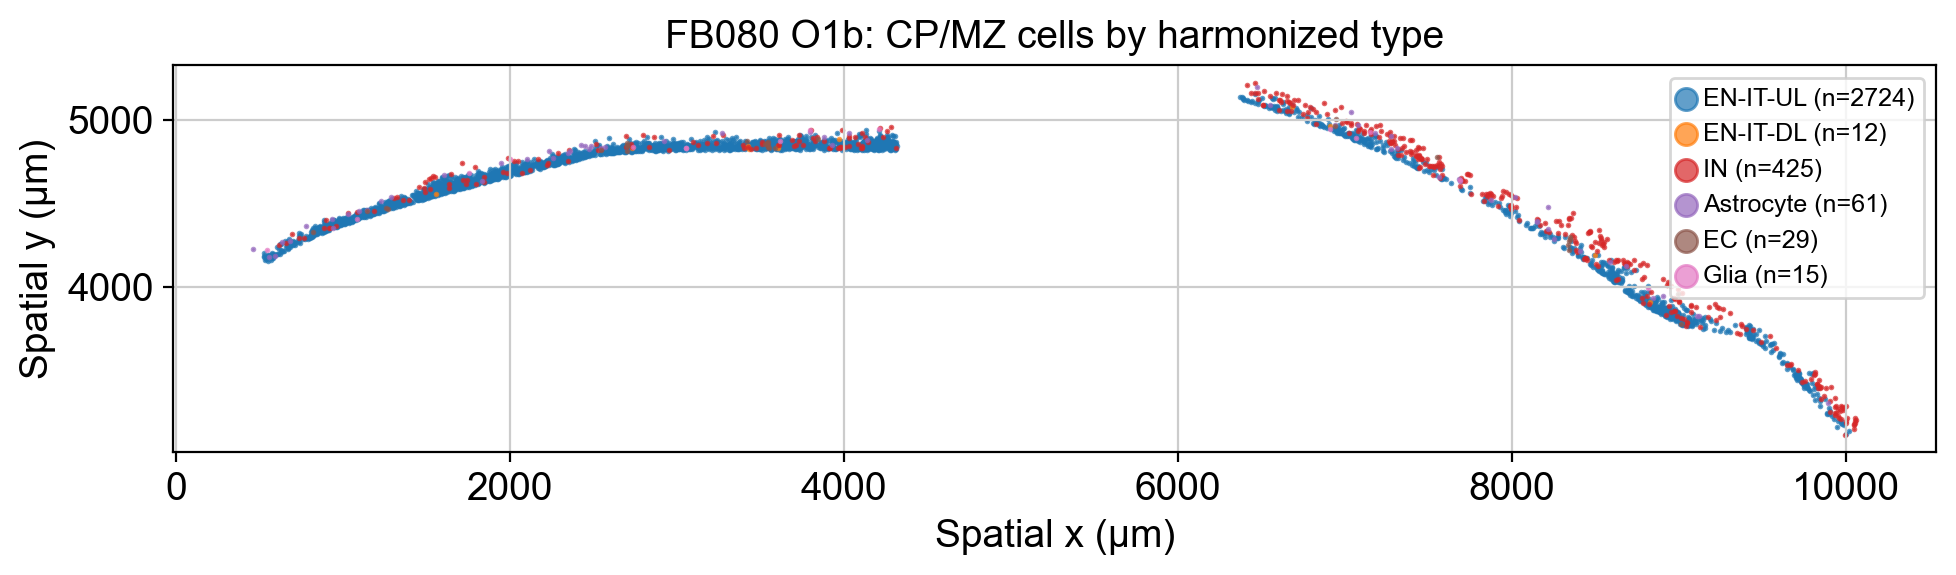

In [7]:
# Focus just on CP/MZ cells, colored by harmonized cell type
cp_mz_mask = section.obs['layer'].isin(['cp', 'mz'])
cp_mz = section[cp_mz_mask]

# Use a discrete palette for cell types
celltype_palette = {
    'EN-IT-UL': '#1f77b4',
    'EN-IT-DL': '#ff7f0e',
    'EN-ET': '#2ca02c',
    'IN': '#d62728',
    'Astrocyte': '#9467bd',
    'EC': '#8c564b',
    'Glia': '#e377c2',
}

fig, ax = plt.subplots(figsize=(10, 12))

for ct, color in celltype_palette.items():
    mask = cp_mz.obs['harmonized'] == ct
    if mask.sum() == 0:
        continue
    ax.scatter(
        cp_mz.obsm['spatial'][mask, 0],
        cp_mz.obsm['spatial'][mask, 1],
        c=color, s=1, alpha=0.7, label=f'{ct} (n={mask.sum()})'
    )

ax.set_aspect('equal')
ax.set_title(f'{TARGET_SAMPLE} {TARGET_REGION}: CP/MZ cells by harmonized type')
ax.set_xlabel('Spatial x (μm)')
ax.set_ylabel('Spatial y (μm)')
ax.legend(loc='upper right', markerscale=8, fontsize=9)
plt.tight_layout()
plt.show()

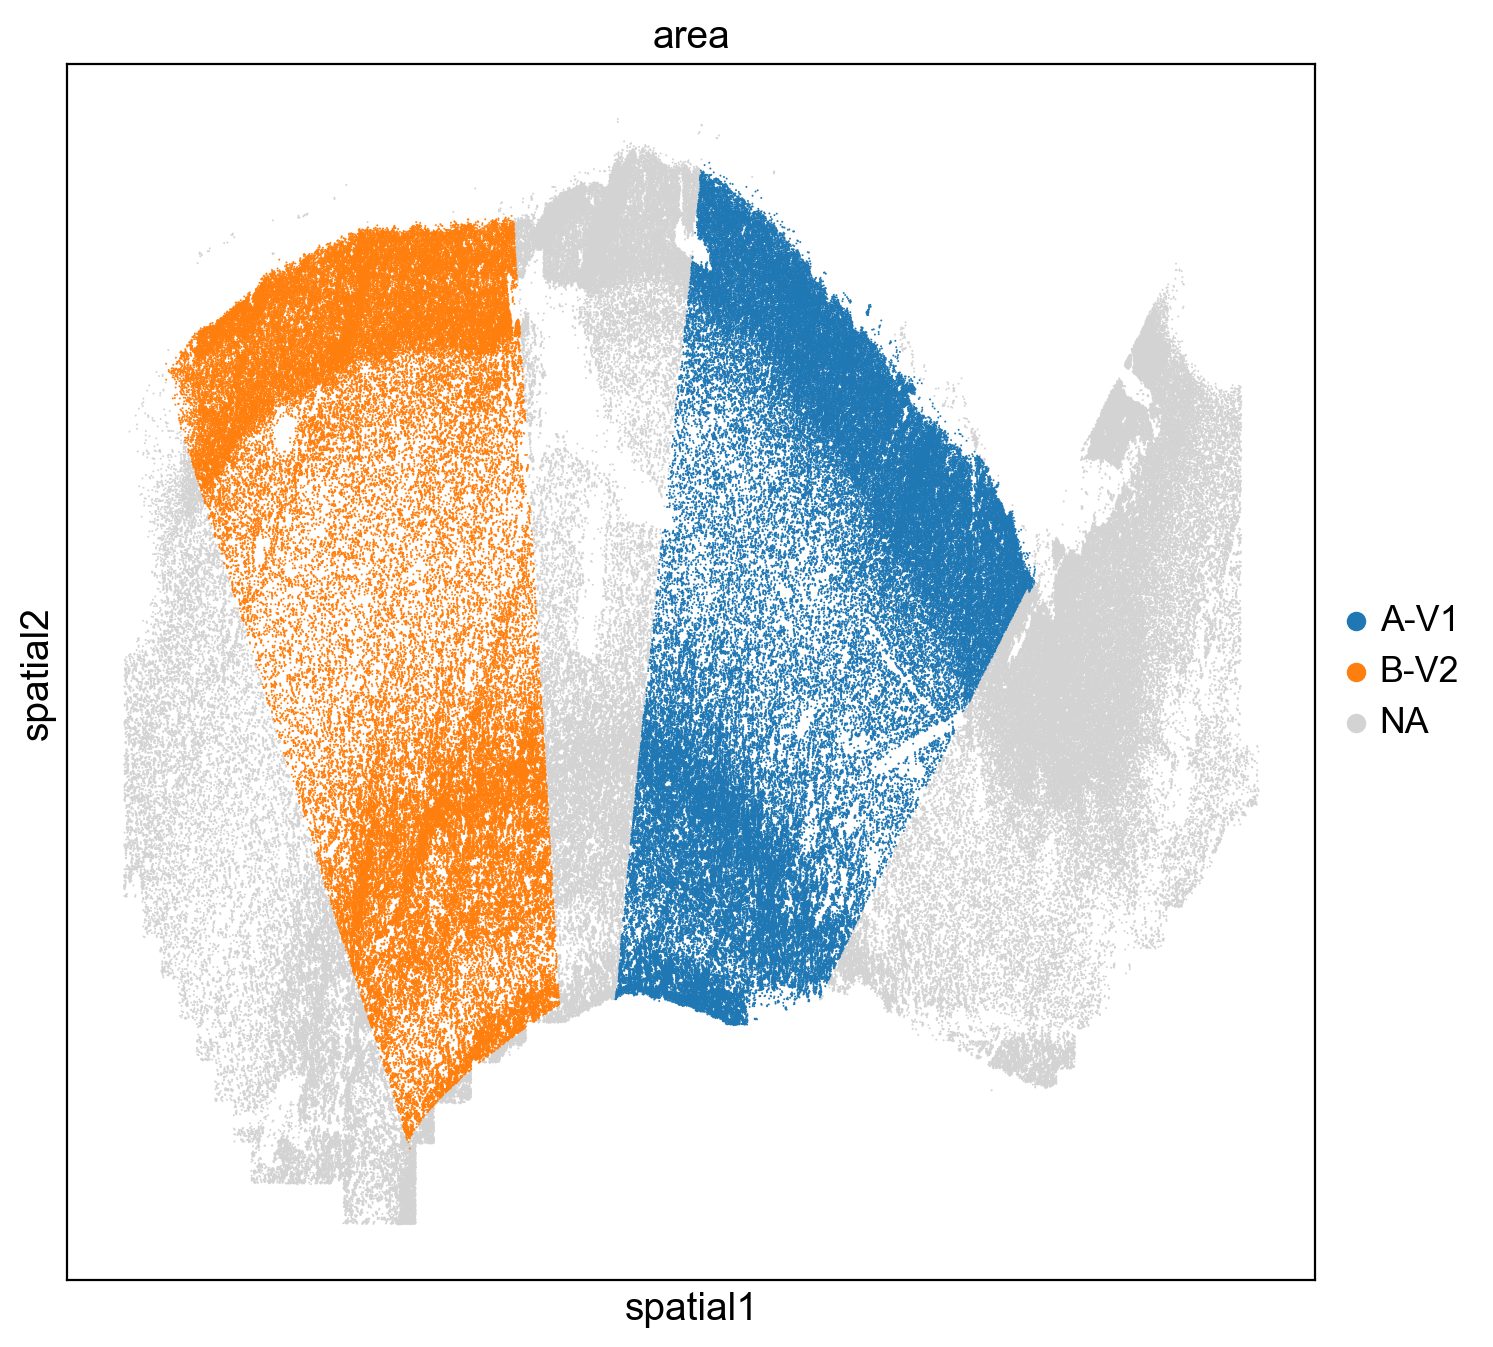

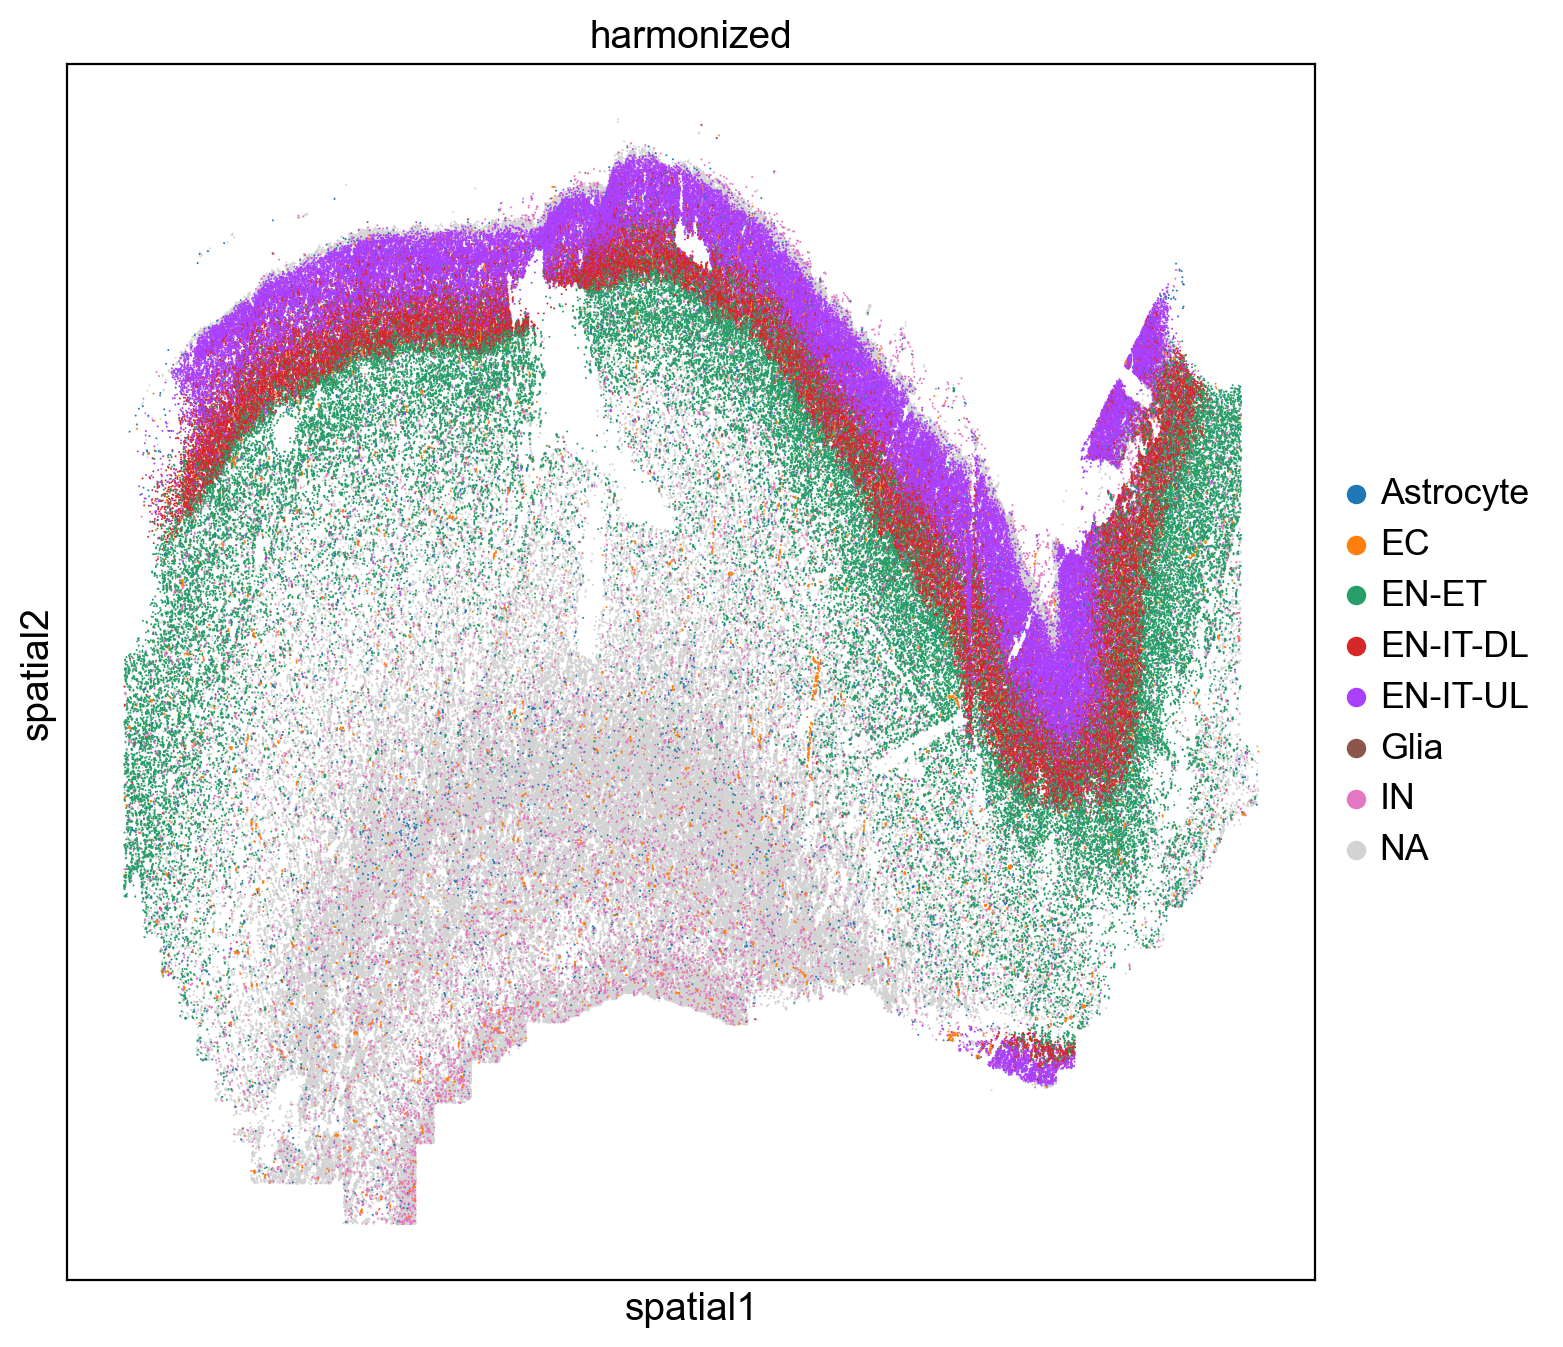

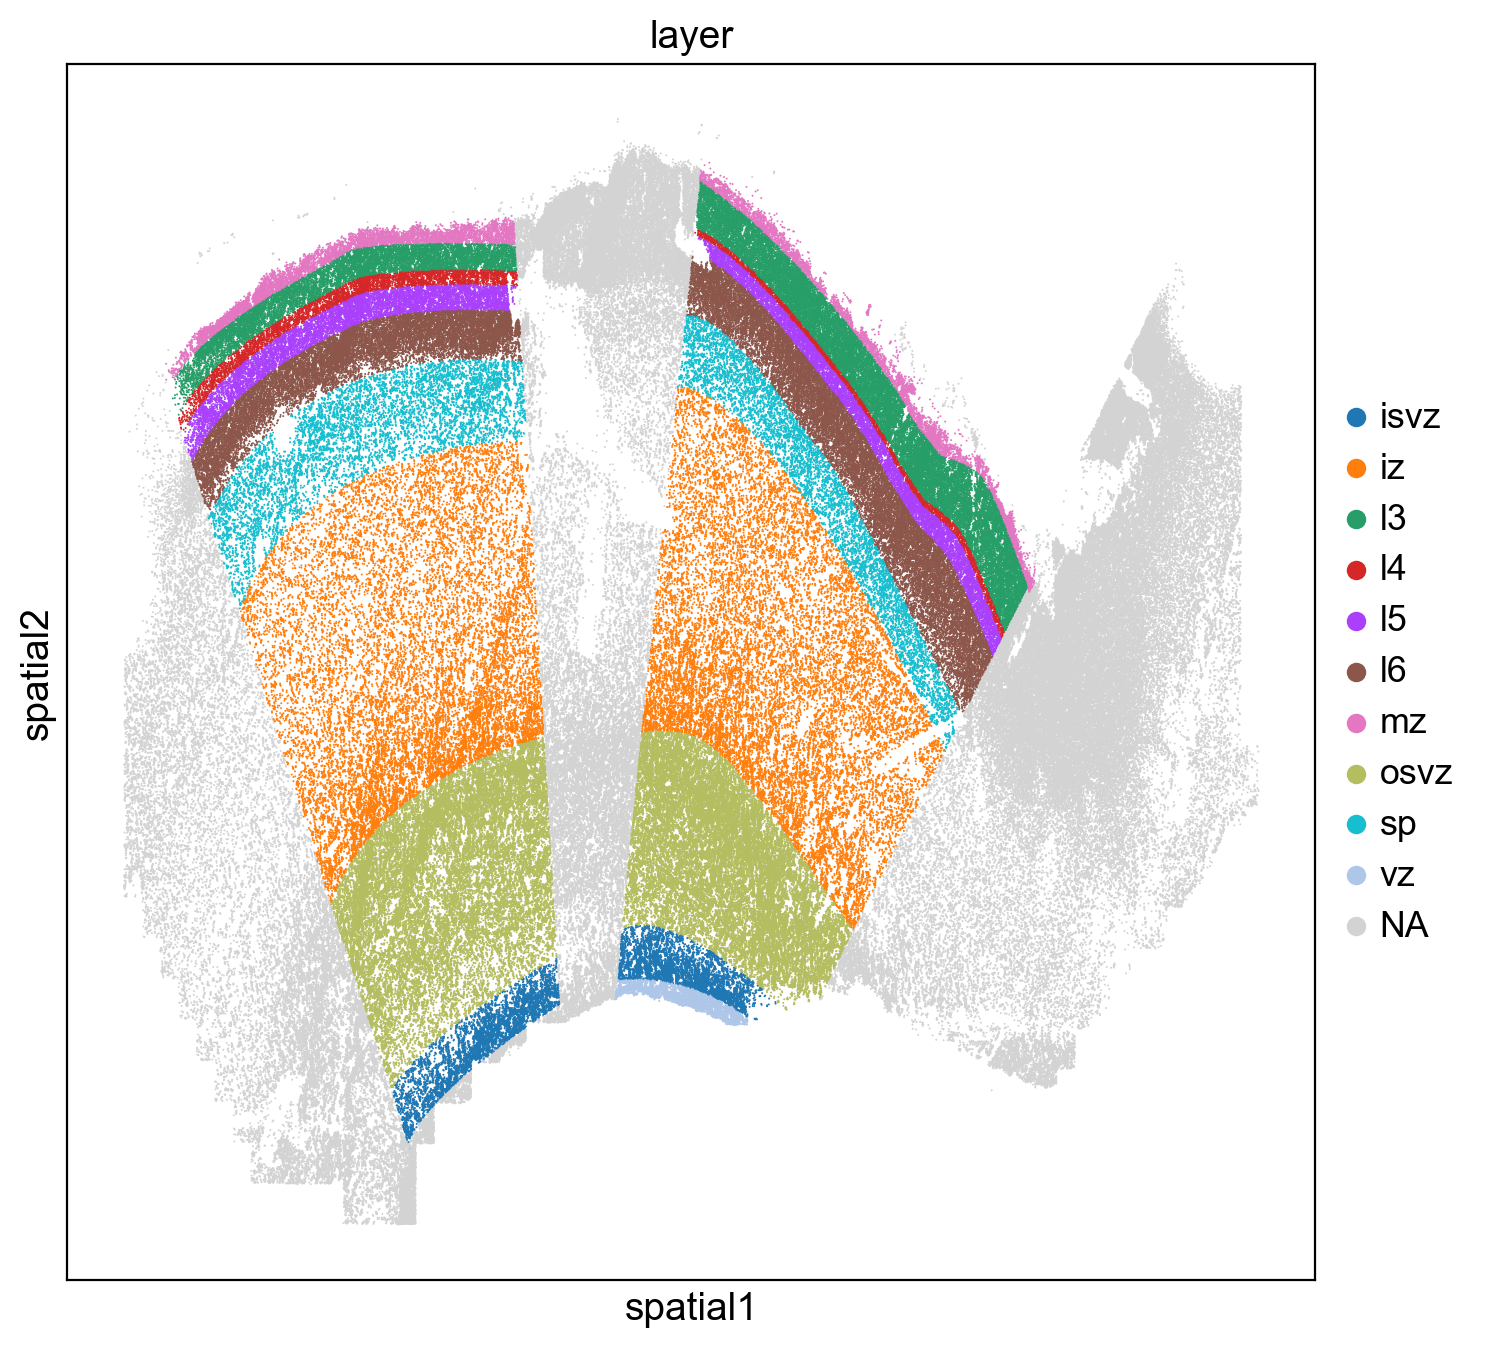

In [8]:
sc.pl.embedding(section, basis='spatial', color='area', size=2)
sc.pl.embedding(section, basis='spatial', color='harmonized', size=2)
sc.pl.embedding(section, basis='spatial', color='layer', size=2)